In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from functions import *
from sklearn import linear_model as lm


In [2]:
#Read in data file (see data_processing.ipynb for how this file is generated)
codes_and_CIs = pd.read_csv('combined_COPUS_CI_data.csv')
#The target variable is the effect size
target = codes_and_CIs['Effect Size'].to_numpy()

ES_variance = codes_and_CIs['Effect Size Variance'].to_numpy()

it_fac = 10

In [3]:
def weighted_LOO_predictions(LOO_predictions, good_fit_BICs, threshhold = 0):
    weights = np.zeros(good_fit_BICs.shape)
    for i in range(data.shape[0]):
        weights[:, i] = BIC_weights(good_fit_BICs[:, i])
    print(f'Minimum BIC: {np.min(good_fit_BICs):.2f}')
    weighted_predictions = np.sum(weights.reshape(-1, 1, data.shape[0]) * LOO_predictions, axis = 1)
    LOO_means = np.mean(weighted_predictions, axis=0)
    #LOO_means = np.mean(LOO_predictions, axis = (0,1  ))

    LOO_stds = np.sum(weights * np.std(LOO_predictions, axis=(1)), axis = 0)
    #LOO_stds = np.std(LOO_predictions, axis=(0, 1))
    LOO_plot(target, LOO_means, LOO_stds, measurement_uncertainty = np.sqrt(ES_variance), 
             threshhold = threshhold, )

In [4]:
def BIC_weights(BICs):
    exp_BICs = np.exp(-0.5 * (BICs - np.min(BICs)))
    return exp_BICs / np.sum(exp_BICs)

### Fourth order: Lec, CG, WG, OG, SQ

Total possible terms:  59
Minimum BIC: -34.89


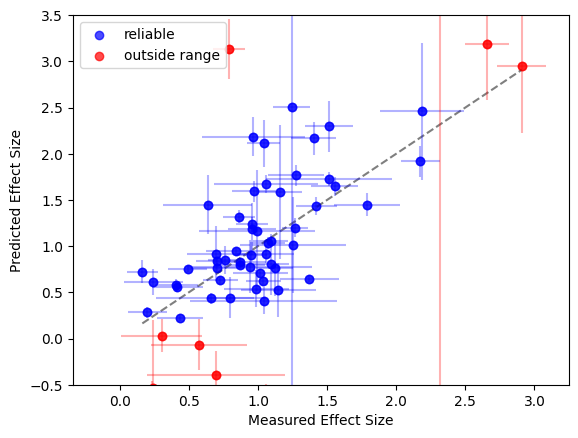

R^2: 0.098
Mean absolute error: 1.9494
Weighted MAE: 7.4862
-----
Removing predictions outside measured range (N = 17):
R^2: 0.425
MAE: 0.3480
Weighted MAE: 1.9086
-----


In [6]:

#these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG', 'OG', 'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)
print("Total possible terms: ", data.shape[1])
#LOO_predictions, LOO_weights, good_fit_BICs = feature_boot_LOO(data, target, ES_variance,)

#np.save('weights/LOO_predictions_all_CG.npy', LOO_predictions)
#np.save('weights/LOO_weights_all_CG.npy', LOO_weights)
#np.save('weights/good_fit_BICs_all_CG.npy', good_fit_BICs)

LOO_predictions = np.load('weights/LOO_predictions_all_CG.npy')
LOO_weights = np.load('weights/LOO_weights_all_CG.npy')
good_fit_BICs = np.load('weights/good_fit_BICs_all_CG.npy')

weighted_LOO_predictions(LOO_predictions, good_fit_BICs,)

## Same but choose CQ over CG

Total possible terms:  59
Minimum BIC: 43.44


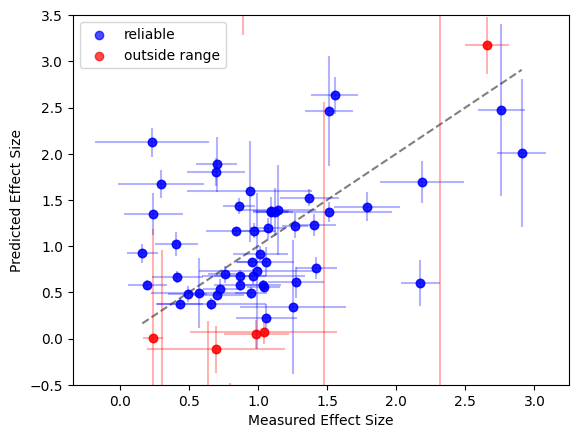

R^2: 0.003
Mean absolute error: 1.7367
Weighted MAE: 8.7167
-----
Removing predictions outside measured range (N = 19):
R^2: 0.155
MAE: 0.4930
Weighted MAE: 2.6512
-----


In [7]:
#Maximum number of codes, choose CG over CQ

#these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CQ', 'WG',  'OG', 'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)
print("Total possible terms: ", data.shape[1])
#LOO_predictions, LOO_weights, good_fit_BICs = feature_boot_LOO(data, target, ES_variance,  )

#np.save('weights/LOO_predictions_all_CQ.npy', LOO_predictions)
#np.save('weights/LOO_weights_all_CQ.npy', LOO_weights)
#np.save('weights/good_fit_BICs_all_CQ.npy', good_fit_BICs)

LOO_predictions = np.load('weights/LOO_predictions_all_CQ.npy')
LOO_weights = np.load('weights/LOO_weights_all_CQ.npy')
good_fit_BICs = np.load('weights/good_fit_BICs_all_CQ.npy')

weighted_LOO_predictions(LOO_predictions, good_fit_BICs,)

## Replace WG and OG with PQ

PQ necessarily happens alongside WG and OG

Total possible terms:  39
Minimum BIC: 107.58


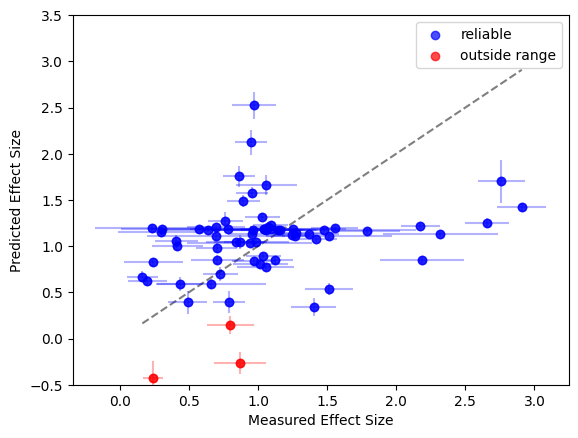

R^2: 0.048
Mean absolute error: 0.5171
Weighted MAE: 2.8055
-----
Removing predictions outside measured range (N = 4):
R^2: 0.050
MAE: 0.4664
Weighted MAE: 2.5772
-----


In [8]:
#replace OG and WG with PQ
#does way worse

#these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'PQ', 'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)
print("Total possible terms: ", data.shape[1])

#LOO_predictions, LOO_weights, good_fit_BICs = feature_boot_LOO(data, target, ES_variance,  )

#np.save('weights/LOO_predictions_PQ.npy', LOO_predictions)
#np.save('weights/LOO_weights_PQ.npy', LOO_weights)
#np.save('weights/good_fit_BICs_PQ.npy', good_fit_BICs)

LOO_predictions = np.load('weights/LOO_predictions_PQ.npy')
LOO_weights = np.load('weights/LOO_weights_PQ.npy')
good_fit_BICs = np.load('weights/good_fit_BICs_PQ.npy')

weighted_LOO_predictions(LOO_predictions, good_fit_BICs,)

## Remove OG: Lec, CG, WG, SQ 

Total possible terms:  39
Minimum BIC: 35.58


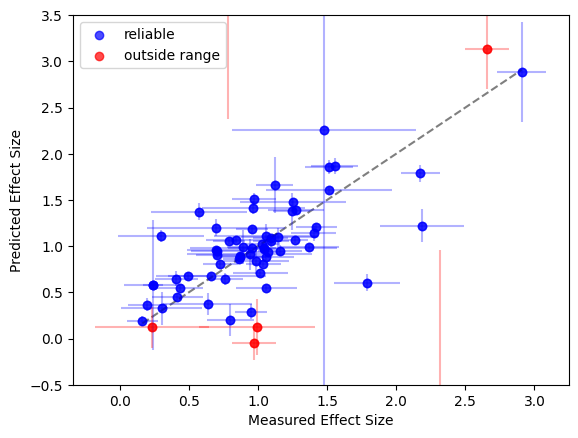

R^2: 0.107
Mean absolute error: 0.4375
Weighted MAE: 1.9800
-----
Removing predictions outside measured range (N = 7):
R^2: 0.521
MAE: 0.2588
Weighted MAE: 1.3627
-----


In [9]:


#these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG',   'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)
print("Total possible terms: ", data.shape[1])

#LOO_predictions, LOO_weights, good_fit_BICs = feature_boot_LOO(data, target, ES_variance,  )

#np.save('weights/LOO_predictions_final.npy', LOO_predictions)
#np.save('weights/LOO_weights_final.npy', LOO_weights)
#np.save('weights/good_fit_BICs_final.npy', good_fit_BICs)

LOO_predictions = np.load('weights/LOO_predictions_final.npy')
good_fit_BICs = np.load('weights/good_fit_BICs_final.npy')

weighted_LOO_predictions(LOO_predictions, good_fit_BICs,)

## Remove Lec: CG, WG, OG,  SQ (only student vars)

Total possible terms:  39
Minimum BIC: 56.35


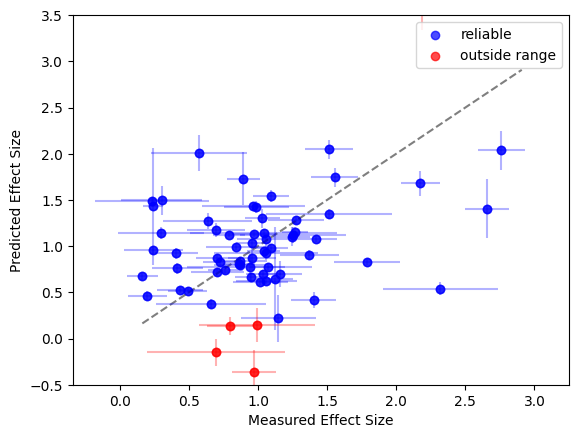

R^2: 0.184
Mean absolute error: 0.6076
Weighted MAE: 2.9530
-----
Removing predictions outside measured range (N = 8):
R^2: 0.069
MAE: 0.4268
Weighted MAE: 2.3201
-----


In [10]:

#these will be input features for the model
data = codes_and_CIs[[ 'WG', 'CG', 'OG', 'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features


data = add_cross_terms(data)
print("Total possible terms: ", data.shape[1])

#LOO_predictions, LOO_weights, good_fit_BICs = feature_boot_LOO(data, target, ES_variance,  )

#np.save('weights/LOO_predictions_no_Lec.npy', LOO_predictions)
#np.save('weights/LOO_weights_no_Lec.npy', LOO_weights)
#np.save('weights/good_fit_BICs_no_Lec.npy', good_fit_BICs)

LOO_predictions = np.load('weights/LOO_predictions_no_Lec.npy')
LOO_weights = np.load('weights/LOO_weights_no_Lec.npy')
good_fit_BICs = np.load('weights/good_fit_BICs_no_Lec.npy')



weighted_LOO_predictions(LOO_predictions, good_fit_BICs, )


## Remove WG: Lec, CG, OG, SQ

Total possible terms:  39
LOO iteration 0 of 69
LOO iteration 10 of 69
LOO iteration 20 of 69
LOO iteration 30 of 69
LOO iteration 40 of 69
LOO iteration 50 of 69
LOO iteration 60 of 69
Minimum BIC: 103.54


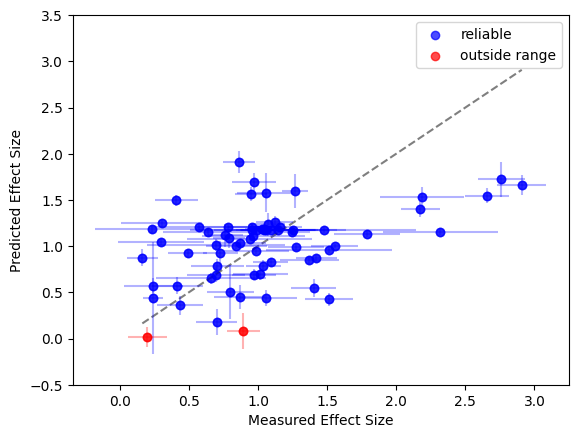

R^2: 0.182
Mean absolute error: 0.4271
Weighted MAE: 2.3948
-----
Removing predictions outside measured range (N = 2):
R^2: 0.165
MAE: 0.4250
Weighted MAE: 2.3451
-----


In [11]:
#remove WG

#these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'OG', 'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)
print("Total possible terms: ", data.shape[1])

#LOO_predictions, LOO_weights, good_fit_BICs = feature_boot_LOO(data, target, ES_variance,  )

#np.save('weights/LOO_predictions_no_WG.npy', LOO_predictions)
#np.save('weights/LOO_weights_no_WG.npy', LOO_weights)
#np.save('weights/good_fit_BICs_no_WG.npy', good_fit_BICs)

LOO_predictions = np.load('weights/LOO_predictions_no_WG.npy')
LOO_weights = np.load('weights/LOO_weights_no_WG.npy')
good_fit_BICs = np.load('weights/good_fit_BICs_no_WG.npy')


weighted_LOO_predictions(LOO_predictions, good_fit_BICs,)

## Remove SQ: Lec, CG, WG, OG

Total possible terms:  39
Minimum BIC: 66.59


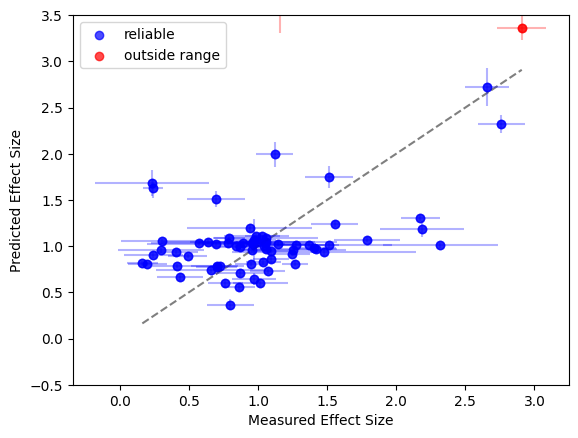

R^2: 0.256
Mean absolute error: 0.3935
Weighted MAE: 2.2370
-----
Removing predictions outside measured range (N = 2):
R^2: 0.229
MAE: 0.3623
Weighted MAE: 2.0397
-----


In [31]:
#remove SQ

#these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG', 'OG',  ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)
print("Total possible terms: ", data.shape[1])

#LOO_predictions, LOO_weights, good_fit_BICs = feature_boot_LOO(data, target, ES_variance,  )

#np.save('weights/LOO_predictions_no_SQ.npy', LOO_predictions)
#np.save('weights/LOO_weights_no_SQ.npy', LOO_weights)
#np.save('weights/good_fit_BICs_no_SQ.npy', good_fit_BICs)

LOO_predictions = np.load('weights/LOO_predictions_no_SQ.npy')
LOO_weights = np.load('weights/LOO_weights_no_SQ.npy')
good_fit_BICs = np.load('weights/good_fit_BICs_no_SQ.npy')

weighted_LOO_predictions(LOO_predictions, good_fit_BICs,)

## Combine WG and OG

Total possible terms:  39
Minimum BIC: 89.45


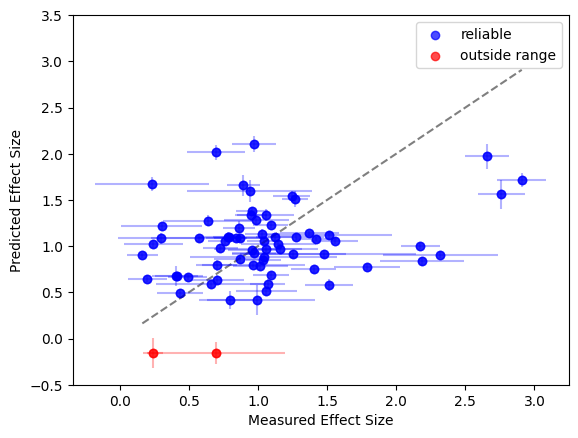

R^2: 0.087
Mean absolute error: 0.4680
Weighted MAE: 2.4242
-----
Removing predictions outside measured range (N = 2):
R^2: 0.060
MAE: 0.4633
Weighted MAE: 2.3880
-----


In [32]:
#combine WG and OG

#these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG', 'OG', 'SQ' ]].to_numpy()
data[:, 2] = data[:, 2] + data[:, 3]
data = data[:, [0, 1, 2, 4]] #remove OG
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)
print("Total possible terms: ", data.shape[1])

#LOO_predictions, LOO_weights, good_fit_BICs = feature_boot_LOO(data, target, ES_variance,  )

#np.save('weights/LOO_predictions_no_OG+WG.npy', LOO_predictions)
#np.save('weights/LOO_weights_no_OG+WG.npy', LOO_weights)
#np.save('weights/good_fit_BICs_no_OG+WG.npy', good_fit_BICs)

LOO_predictions = np.load('weights/LOO_predictions_no_OG+WG.npy')
LOO_weights = np.load('weights/LOO_weights_no_OG+WG.npy')
good_fit_BICs = np.load('weights/good_fit_BICs_no_OG+WG.npy')


weighted_LOO_predictions(LOO_predictions, good_fit_BICs,)

Total possible terms:  39
Minimum BIC: 84.37


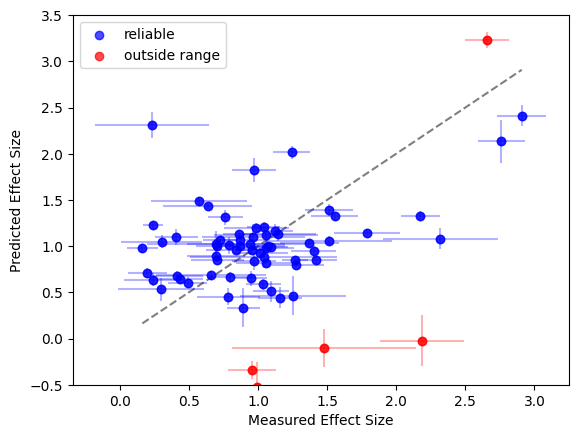

R^2: 0.100
Mean absolute error: 0.5037
Weighted MAE: 2.6927
-----
Removing predictions outside measured range (N = 6):
R^2: 0.157
MAE: 0.4060
Weighted MAE: 2.3120
-----


In [34]:
#combine CG and OG

#these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG', 'OG', 'SQ' ]].to_numpy()
data[:, 1] = data[:, 1] + data[:, 3]
data = data[:, [0, 1, 2, 4]] #remove OG
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)
print("Total possible terms: ", data.shape[1])

#LOO_predictions, LOO_weights, good_fit_BICs = feature_boot_LOO(data, target, ES_variance,  )

#np.save('weights/LOO_predictions_OG+CG.npy', LOO_predictions)
#np.save('weights/LOO_weights_OG+CG.npy', LOO_weights)
#np.save('weights/good_fit_BICs_OG+CG.npy', good_fit_BICs)

LOO_predictions = np.load('weights/LOO_predictions_OG+CG.npy')
LOO_weights = np.load('weights/LOO_weights_OG+CG.npy')
good_fit_BICs = np.load('weights/good_fit_BICs_OG+CG.npy')


weighted_LOO_predictions(LOO_predictions, good_fit_BICs,)

Total possible terms:  39
LOO iteration 0 of 69
LOO iteration 10 of 69
LOO iteration 20 of 69
LOO iteration 30 of 69
LOO iteration 40 of 69
LOO iteration 50 of 69
LOO iteration 60 of 69
Minimum BIC: 43.12


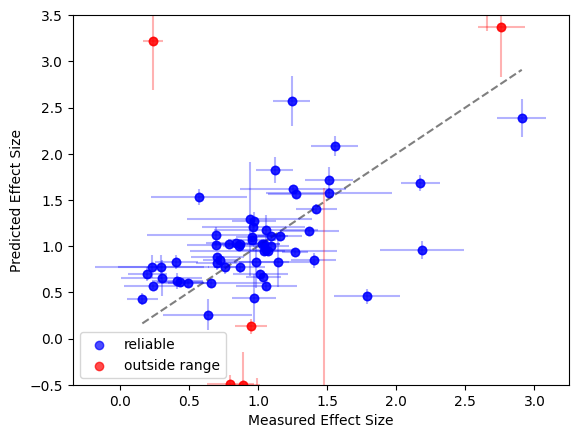

R^2: 0.193
Mean absolute error: 0.6808
Weighted MAE: 3.3946
-----
Removing predictions outside measured range (N = 10):
R^2: 0.347
MAE: 0.3201
Weighted MAE: 1.6743
-----


In [33]:
#combine CG and WG

#these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG', 'OG', 'SQ' ]].to_numpy()
data[:, 1] = data[:, 1] + data[:, 2]
data = data[:, [0, 1, 2, 4]] #remove OG
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)
print("Total possible terms: ", data.shape[1])

LOO_predictions, LOO_weights, good_fit_BICs = feature_boot_LOO(data, target, ES_variance,  )

np.save('weights/LOO_predictions_WG+CG.npy', LOO_predictions)
np.save('weights/LOO_weights_WG+CG.npy', LOO_weights)
np.save('weights/good_fit_BICs_WG+CG.npy', good_fit_BICs)

LOO_predictions = np.load('weights/LOO_predictions_WG+CG.npy')
LOO_weights = np.load('weights/LOO_weights_WG+CG.npy')
good_fit_BICs = np.load('weights/good_fit_BICs_WG+CG.npy')


weighted_LOO_predictions(LOO_predictions, good_fit_BICs,)

## Combine all group work

Total possible terms:  25
LOO iteration 0 of 69
LOO iteration 10 of 69
LOO iteration 20 of 69
LOO iteration 30 of 69
LOO iteration 40 of 69
LOO iteration 50 of 69
LOO iteration 60 of 69
Minimum BIC: 104.90


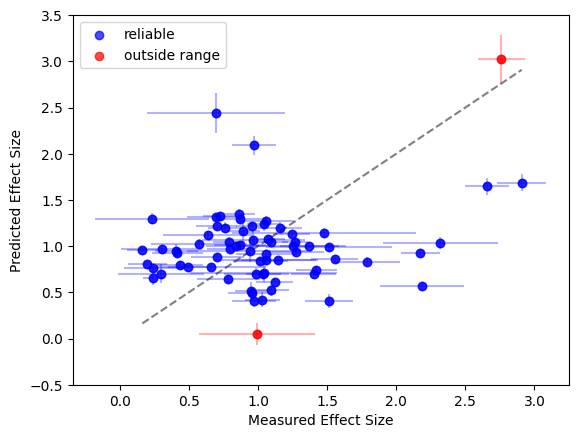

R^2: 0.079
Mean absolute error: 0.4953
Weighted MAE: 2.6563
-----
Removing predictions outside measured range (N = 2):
R^2: 0.011
MAE: 0.4921
Weighted MAE: 2.6796
-----


In [15]:
#combine all group work

#combine WG and OG

#these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG', 'OG', 'SQ' ]].to_numpy()
data[:, 2] = data[:, 2] + data[:, 3] + data[:, 1]
data = data[:, [0,  2, 4]] #remove OG
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)
print("Total possible terms: ", data.shape[1])

LOO_predictions, LOO_weights, good_fit_BICs = feature_boot_LOO(data, target, ES_variance,  )

np.save('weights/LOO_predictions_OG+CG+WG.npy', LOO_predictions)
np.save('weights/LOO_weights_OG+CG+WG.npy', LOO_weights)
np.save('weights/good_fit_BICs_OG+CG+WG.npy', good_fit_BICs)

LOO_predictions = np.load('weights/LOO_predictions_OG+CG+WG.npy')
LOO_weights = np.load('weights/LOO_weights_OG+CG+WG.npy')
good_fit_BICs = np.load('weights/good_fit_BICs_OG+CG+WG.npy')


weighted_LOO_predictions(LOO_predictions, good_fit_BICs,)

# Model Complexity

In [16]:
#up to third order terms

def add_cross_terms_3(data):
    ## this functions adds polynomial and cross terms to the data
        
    pts, features = data.shape
    #
    cross_factors = (data[:, :features].reshape(pts, 1, features) *data[:, :features].reshape(pts, features, 1))#.reshape(pts, features * features)
    #keep only upper triangle

    #second order terms
    cross_factors = cross_factors[:, np.triu_indices(features, k=1)[0], np.triu_indices(features, k=1)[1]]
    cross_factors = np.hstack((cross_factors, data**2))

    #third order terms
    cross_21 = (data.reshape(pts, 1, features)**2 * data.reshape(pts, features, 1))
    cross_12 = (data.reshape(pts, 1, features) * data.reshape(pts, features, 1)**2)


    cross_factors = np.hstack((cross_factors, cross_21[:, np.triu_indices(features, k=1)[0], np.triu_indices(features, k=1)[1]]))
    cross_factors = np.hstack((cross_factors, cross_12[:, np.triu_indices(features, k=1)[0], np.triu_indices(features, k=1)[1]]))


    data = np.hstack((data, cross_factors))

    

    data = np.hstack((data, data[:, :1]*data[:, 1:2]* data[:, 2:3]))  # interaction term for first three features
    if features >= 4:
        data = np.hstack((data, data[:, :1]*data[:, 1:2]* data[:, 3:4]))  # interaction term for first second and fourth features
        data = np.hstack((data, data[:, :1]*data[:, 2:3]* data[:, 3:4]))  # interaction term for first third and fourth features
        data = np.hstack((data, data[:, 1:2] * data[:, 2:3] * data[:, 3:4]))  # interaction term for second third and fourth features
    
    #######################
    if features >= 5:
        data = np.hstack((data, data[:, :1] * data[:, 1:2] * data[:, 4:5]))  # interaction term for first second and fifth features
        data = np.hstack((data, data[:, :1] * data[:, 2:3] * data[:, 4:5]))  # interaction term for first third and fifth features
        data = np.hstack((data, data[:, :1] * data[:, 3:4] * data[:, 4:5]))  # interaction term for first fourth and fifth features
        data = np.hstack((data, data[:, 1:2] * data[:,  2:3] * data[:, 4:5]))  # interaction term for second third and fifth features
        data = np.hstack((data, data[:, 1:2] * data[:, 3:4] * data[:, 4:5]))  # interaction term for second fourth and fifth features
        data = np.hstack((data, data[:, 2:3] * data[:, 3:4] * data[:, 4:5]))  # interaction term for third fourth and fifth features
        ########################
    data = np.hstack((data, data[:, :4]**3))  #third order ter

    data = np.hstack((data, np.ones((data.shape[0], 1))))  # add bias term
    return data


Total possible terms:  55
Minimum BIC: 38.56


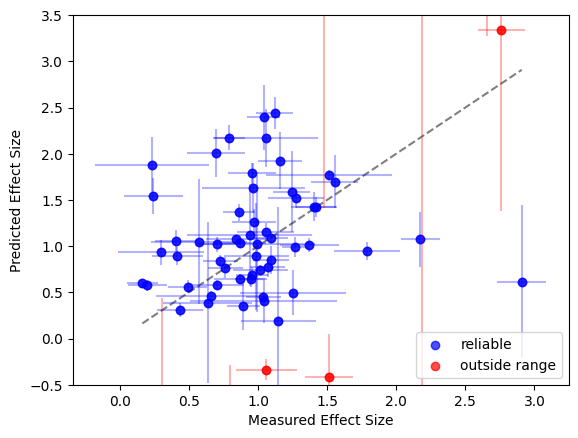

R^2: 0.000
Mean absolute error: 1.2684
Weighted MAE: 6.8991
-----
Removing predictions outside measured range (N = 14):
R^2: 0.009
MAE: 0.5189
Weighted MAE: 2.8888
-----


In [23]:
#up to thrid order
# #these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG',  'OG', 'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms_3(data)

print("Total possible terms: ", data.shape[1])

#LOO_predictions, LOO_weights, good_fit_BICs = feature_boot_LOO(data, target, ES_variance,  )

#np.save('weights/LOO_predictions_all_3.npy', LOO_predictions)
#np.save('weights/LOO_weights_all_3.npy', LOO_weights)
#np.save('weights/good_fit_BICs_all_3.npy', good_fit_BICs)

LOO_predictions = np.load('weights/LOO_predictions_all_3.npy')
LOO_weights = np.load('weights/LOO_weights_all_3.npy')
good_fit_BICs = np.load('weights/good_fit_BICs_all_3.npy')


weighted_LOO_predictions(LOO_predictions, good_fit_BICs, threshhold = 0)

Total possible terms:  35
Minimum BIC: 57.13


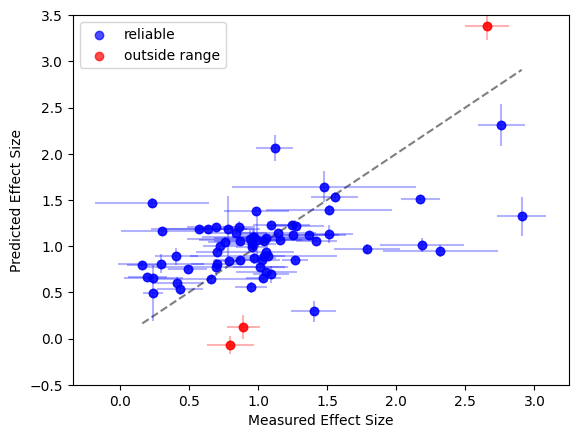

R^2: 0.289
Mean absolute error: 0.3688
Weighted MAE: 2.0263
-----
Removing predictions outside measured range (N = 3):
R^2: 0.222
MAE: 0.3498
Weighted MAE: 1.8755
-----


In [24]:
#up to thrid order
# #these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG',   'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms_3(data)

print("Total possible terms: ", data.shape[1])

#LOO_predictions, LOO_weights, good_fit_BICs = feature_boot_LOO(data, target, ES_variance,  )

#np.save('weights/LOO_predictions_no_OG_3.npy', LOO_predictions)
#np.save('weights/LOO_weights_no_OG_3.npy', LOO_weights)
#np.save('weights/good_fit_BICs_no_OG_3.npy', good_fit_BICs)

LOO_predictions = np.load('weights/LOO_predictions_no_OG_3.npy')
LOO_weights = np.load('weights/LOO_weights_no_OG_3.npy')
good_fit_BICs = np.load('weights/good_fit_BICs_no_OG_3.npy')


weighted_LOO_predictions(LOO_predictions, good_fit_BICs, threshhold = 0)

In [25]:
#up to second order terms

def add_cross_terms_2(data):
    ## this functions adds polynomial and cross terms to the data
        
    pts, features = data.shape
    #
    cross_factors = (data[:, :features].reshape(pts, 1, features) *data[:, :features].reshape(pts, features, 1))#.reshape(pts, features * features)
    #keep only upper triangle

    #second order terms
    cross_factors = cross_factors[:, np.triu_indices(features, k=1)[0], np.triu_indices(features, k=1)[1]]
    cross_factors = np.hstack((cross_factors, data**2))


    data = np.hstack((data, cross_factors))

    data = np.hstack((data, np.ones((data.shape[0], 1))))  # add bias term
    return data


Total possible terms:  15
Minimum BIC: 70.87


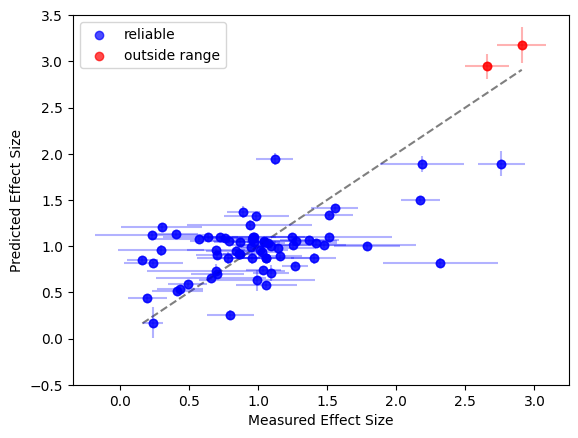

R^2: 0.478
Mean absolute error: 0.3151
Weighted MAE: 1.6524
-----
Removing predictions outside measured range (N = 2):
R^2: 0.282
MAE: 0.3162
Weighted MAE: 1.6524
-----


In [26]:
#add in PQ, up to second
# #these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG',   'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms_2(data)
print("Total possible terms: ", data.shape[1])

#LOO_predictions, LOO_weights, good_fit_BICs = feature_boot_LOO(data, target, ES_variance,  )

#np.save('weights/LOO_predictions_no_OG_2.npy', LOO_predictions)
#np.save('weights/LOO_weights_no_OG_2.npy', LOO_weights)
#np.save('weights/good_fit_BICs_no_OG_2.npy', good_fit_BICs)

LOO_predictions = np.load('weights/LOO_predictions_no_OG_2.npy')
LOO_weights = np.load('weights/LOO_weights_no_OG_2.npy')
good_fit_BICs = np.load('weights/good_fit_BICs_no_OG_2.npy')

weighted_LOO_predictions(LOO_predictions, good_fit_BICs, threshhold = 0)

Total possible terms:  6
Minimum BIC: 122.74


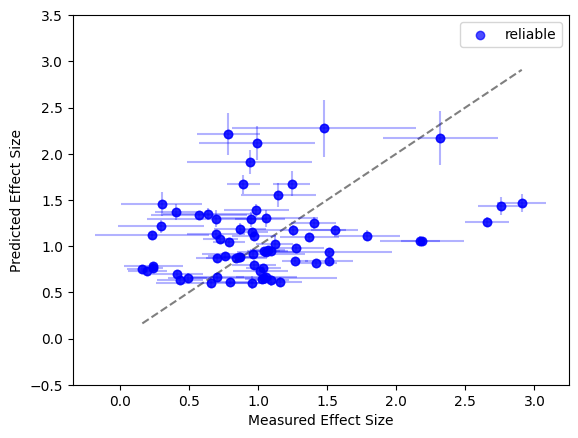

R^2: 0.078
Mean absolute error: 0.4730
Weighted MAE: 2.4751
-----


In [27]:
#first order

#these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG', 'SQ', 'OG',  ]].to_numpy()
#add bias term
data = np.hstack((data, np.ones((data.shape[0], 1))))

print("Total possible terms: ", data.shape[1])

#LOO_predictions, LOO_weights, good_fit_BICs = feature_boot_LOO(data, target, ES_variance,  )

#np.save('weights/LOO_predictions_all_1.npy', LOO_predictions)
#np.save('weights/LOO_weights_all_1.npy', LOO_weights)
#np.save('weights/good_fit_BICs_all_1.npy', good_fit_BICs)

LOO_predictions = np.load('weights/LOO_predictions_all_1.npy')
LOO_weights = np.load('weights/LOO_weights_all_1.npy')
good_fit_BICs = np.load('weights/good_fit_BICs_all_1.npy')


weighted_LOO_predictions(LOO_predictions, good_fit_BICs, threshhold = 0)

Total possible terms:  5
Minimum BIC: 124.52


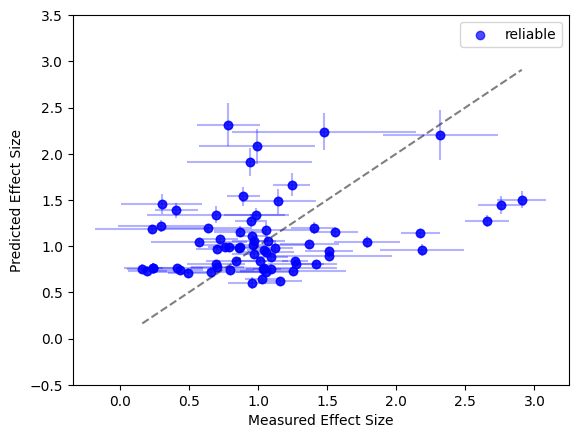

R^2: 0.076
Mean absolute error: 0.4659
Weighted MAE: 2.4366
-----


In [30]:
#first order

#these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG', 'SQ', ]].to_numpy()
#add bias term
data = np.hstack((data, np.ones((data.shape[0], 1))))

print("Total possible terms: ", data.shape[1])

#LOO_predictions, LOO_weights, good_fit_BICs = feature_boot_LOO(data, target, ES_variance,  )

#np.save('weights/LOO_predictions_no_OG_1.npy', LOO_predictions)
#np.save('weights/LOO_weights_no_OG_1.npy', LOO_weights)
#np.save('weights/good_fit_BICs_no_OG_1.npy', good_fit_BICs)

LOO_predictions = np.load('weights/LOO_predictions_no_OG_1.npy')
LOO_weights = np.load('weights/LOO_weights_no_OG_1.npy')
good_fit_BICs = np.load('weights/good_fit_BICs_no_OG_1.npy')

weighted_LOO_predictions(LOO_predictions, good_fit_BICs, threshhold = 0)